<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

<font size=6>**Welcome to the Lensing Challenge!**</font>

<div style="border-left: 5px solid #2878b5; padding: 12px 20px; margin: 20px 0;">
  <p style="font-size: 18px; margin: 0 0 8px;">
    <strong>TALES School II</strong><br>
    Hands-on workshop on machine learning applications to astrophysics
  </p>
  <p style="color: #666; margin: 0;">
    September 13–18, 2026 · Petnica Science Center, Serbia
  </p>
</div>

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

This Hackathon is a chance to put your astronomy, statistics, and coding skills into practice, work together, and try out new ideas.

Your challenge is to **estimate time delays** from the supplied lensed light curves — Explore the data, develop your method, and collect your predictions.

Start with a simple approach, compare ideas with your teammates, and build from there. 

&emsp;&emsp; Happy hacking!

</div>

# Data

## The Generative Process

The data simulate **light curves** received from the [multiple] images of a lensed quasar — Just like in the animation below.

The data have been produced by **varying** the:
- **light source** (_flux, intrinsic variability, etc._)
- **lens** (_lens mass, microlensing effects_)
- **measurements effects** (_cadence of measurement, gaps_)

The purpose was to cover the **variety** of possible observations you may encounter in the field.

&emsp;&emsp; But, worry not!

You do not need to investigate the cause of such variety, in order to solve the exercise.

## Light Curves

Let us have a look at a couple of examples of the data you will receive.

Each system can be either a doubly or quadruply lensed quasar, resulting in either two or four light curves (one for each image of the quasar). In practice, a single pointing of a telescope will result in adding a point in each of the light curves as long as one can perform accurate photometry by deblending the multiple images of the quasar from each other and from the lens galaxy light. This can actually be quite challenging; [Neira et al. 2025](https://ui.adsabs.harvard.edu/abs/2025arXiv250416249N/abstract) present a challenge to obtain accurate light curves from a set of images with varying seeing, point spread function (PSF), and, most importantly, overlap of the lens and lensed quasar flux. Once photometry is obtained, then each light curve is simply a series of flux measurements (with errors) over time. This is illustrated in the animation below for a quadruply imaged quasar (the errors on the flux measurements are not shown).

SPLIT THE VIDEO IN TWO PARTS - THIS FIRST PART SHOULD STOP AT 10s.

In [2]:
from IPython.display import Video, display
display(Video("videos/preprocessing.mp4", embed=False, width=800))

We provide the light curve data for each system that we will examine in this exercise in a `.json` file, which is basically just a **list** containing either two or four light curves.

Each light curve entry in this list is a **dictionary** containing:
- the *flux* ("signal", in mag in some arbitrary optical filter),
- the *timestamp* ("time", in days, from some arbitrary reference), and
- the *error* on the flux ("dsingal", same units as the flux).

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<b>WARNING:</b> The order of the light curves in the `.json` file is important and should not be changed. The light curve index in this list is used to label it, which is crucial for labeling the time-delay for each light curve pair, as we will see below.
</div>

Let's read and plot such a file.

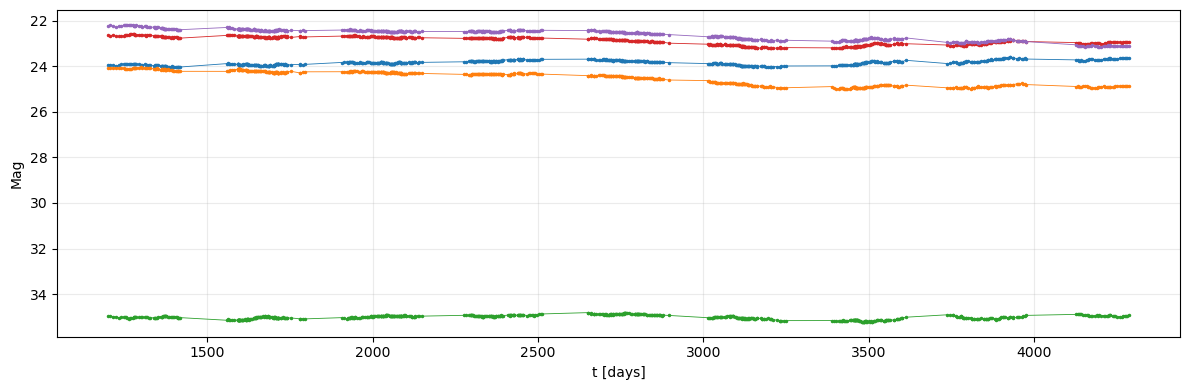

Light curve label: '0'


,dsignal,signal,time
0,22.200953,23.934294,1200.00
1,22.200950,23.931005,1206.99
2,22.200946,23.962836,1214.01


Light curve label: '1'


,dsignal,signal,time
0,22.193681,24.083736,1200.00
1,22.193687,24.083193,1206.99
2,22.193693,24.077385,1214.01


Light curve label: '2'


,dsignal,signal,time
0,22.19,34.966851,1200.00
1,22.19,34.964448,1206.99
2,22.19,34.987801,1214.01


Light curve label: '3'


,dsignal,signal,time
0,22.194173,22.645370,1200.00
1,22.194171,22.658768,1206.99
2,22.194169,22.640693,1214.01


Light curve label: '4'


,dsignal,signal,time
0,22.192514,22.224430,1200.00
1,22.192518,22.211898,1206.99
2,22.192522,22.240952,1214.01


In [5]:
###########
# GV TO DO:
#   - UPLOAD A NEW EXAMPLE FILE WITHOUT THE CENTRAL IMAGE AND MEANINGFUL ERROR BARS
#   - INCLUDE THE ERROR BAR IN THE PLOT
###########

import json
import pandas as pd
import matplotlib.pyplot as plt


def read_light_curves(path_to_file):
    """Load light curves from a JSON file into a dictionary of DataFrames.

    Parameters
    ----------
    path_to_file : str or path-like
        Path to a JSON file containing a list of light-curve dictionaries.
        Each dictionary contains equal-length arrays: ``time`` (days),
        ``signal`` (magnitudes), and ``dsignal`` (signal uncertainties).

    Returns
    -------
    dict[int, pandas.DataFrame]
        Light curves indexed by their zero-based position in the file.
        Each DataFrame has one row per observation and preserves the
        original column names and values.
    """

    with open(path_to_file, encoding="utf-8") as fh:
        curves = json.load(fh)

    df_curves = {}
    for i, curve in enumerate(curves):
        df_curves[i] = pd.DataFrame(curve)

    return df_curves


def plot_light_curves(dict_of_lcs):
    """Plot light curves previously read from a JSON file.

    Parameters
    ----------
    dict_of_lcs: dict[int, pandas.DataFrame]
        Light curves indexed by their zero-based position in the file.
        Each DataFrame has one row per observation and preserves the
        original column names and values. This can be the output of the 
        'read_light_curves' function defined above.
        
    Returns
    -------
    A matplotlib plot.
    """
        
    fig, ax = plt.subplots(figsize=(12, 4))
    for i, df_curve in curves_dict.items():
        ax.plot(df_curve["time"], df_curve["signal"], ".-", ms=3, lw=0.6)
        ax.invert_yaxis()
        ax.grid(alpha=0.25)
        ax.set(xlabel="t [days]", ylabel="Mag")
    plt.tight_layout()
    plt.show()


LC_FILE = "mock_data/testCAM-i_LC_sampled 99.json"

lcs = read_light_curves(LC_FILE)

plot_light_curves(lcs)

# Display some of the light curve data directly from the dict of pandas dataframes
for i, df_curve in lcs.items():
    print( "Light curve label: '{label}'".format(label=i) )
    display(df_curve.head(3))

# The Challenge

**Objective:** For every lensed quasar, estimate the time delays between each **pair** of lensed light curves.

The time-delay between each pair of light curves has to be labelled using the labels of the light curves.

- _If it is a double, then you will have to report only one time delay: $\Delta t_{01}$ (between light curves '0' and '1')_
- _For quads, there are only three truly independent time-delays. You will need to report these three values with **respect to the leading image** (first in the .json file, labeled '0'), that is: $\Delta t_{01}$, $\Delta t_{02}$ and $\Delta t_{03}$._


### Training data

You will receive data for XXX lensed quasars, both quads and doubles, with given time-delays that you can use for training your algorithms. The light curves are in `.json` files, one for each lens, which you can find here:

LINK TO THE .JSON FILES

You will also receive a *master* `.csv` file with the following information:

$$
\begin{array}{ll}
\text{Column name} & \text{Description} \\
\hline
\textbf{id} & \text{An alphanumeric id to distinguish each lens. The corresponding light curves will be in a file named `<id>.json`.} \\
\textbf{flag} & \text{An integer indicating whether the lens is a double (2) or a quad (4).} \\
\textbf{01} & \text{The true time delay (in days) between light curves '0' and '1'.} \\
\textbf{02} & \text{The true time delay (in days) between light curves '0' and '2'. For a double lens, this will be set to 'NA'.} \\
\textbf{03} & \text{The true time delay (in days) between light curves '0' and '3'. For a double lens, this will be set to 'NA'.} \\
\hline
\end{array}
$$




### Challenge data

You can obtain the actual challenge light curves here:

LINK TO THE .JSON FILES

Similarly to the training set above, you will receive a pre-formatted *master* `.csv` file, containing the **id**, **flag**, and having prefilled 'NA' values where appropriate. You will need to complete this file with your final answers and submit it. **This will be your final submission**.





<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">


**Delivarable:** Produce a pandas file.

----------- Complete after data structure is finalized
----------- Complete after data structure is finalized
----------- Complete after data structure is finalized



**Assessment:** Minimize the **Root Mean Square Error** (**RMSE**) between the 

----------- Complete after data structure is finalized
----------- Complete after data structure is finalized
----------- Complete after data structure is finalized


</div>

## Metric

In [72]:
# You do not own this
df_truth = pd.DataFrame(columns=["ID", "dt_01_days", "dt_02_days", "dt_03_days"])

df_truth.loc[len(df_truth)] = ["AAA", 0.11, "NA", "NA"]  # double system
df_truth.loc[len(df_truth)] = ["BBB", 0.13, 0.19, 0.31]  # quad system
df_truth.loc[len(df_truth)] = ["CCC", 0.13, 0.19, 0.31]  # malfomed line (ID does not exists), will be skipped by the scorer

display(df_truth)


,ID,dt_01_days,dt_02_days,dt_03_days
0,AAA,0.11,NA,NA
1,BBB,0.13,0.19,0.31
2,CCC,0.13,0.19,0.31


In [73]:
# You submit this
df_results = pd.DataFrame(columns=["ID", "dt_01_days", "dt_02_days", "dt_03_days"])

df_results.loc[len(df_results)] = ["AAA", 0.10, "NA", "NA"]   # double system
df_results.loc[len(df_results)] = ["BBB", 0.11, 0.22, 0.33]  # You do not own this# quad system

display(df_results)


,ID,dt_01_days,dt_02_days,dt_03_days
0,AAA,0.10,NA,NA
1,BBB,0.11,0.22,0.33


In [76]:
import numpy as np

def score(df_results, df_truth):
    """Return the root mean squared error (RMSE) in days.
    
    Compute the square root of the average squared error across all matched
    IDs and all three time-delay columns. Skip pairs where either value is
    missing ("NA", "NaN", or np.nan). Return NaN if no valid pairs remain.

    Parameters
    ----------
    df_results, df_truth : pandas.DataFrame
        Predicted and reference values, respectively. Each must contain
        ``ID``, ``dt_01_days``, ``dt_02_days``, and ``dt_03_days``.
        Only IDs present in both frames are scored (inner join).

    Returns
    -------
    float
        Square root of the mean squared difference across all valid delay
        pairs, with equal weight per pair. Lower is better; zero is exact.
        Returns NaN if no valid pairs remain.

    Notes
    -----
    Numeric strings are accepted. Missing values (including the strings
    "NA" and "NaN", and np.nan) and other nonnumeric values are coerced
    to NaN. A pair is excluded if either value is missing.
    Displays the first five comparison rows with signed errors.
    """
    
    df_comparison = df_truth.merge(
        df_results, on="ID", suffixes=("_truth", "_result")
    )
    
    for col in ["dt_01_days", "dt_02_days", "dt_03_days"]:
        truth  = pd.to_numeric(df_comparison[f"{col}_truth"],  errors="coerce")
        result = pd.to_numeric(df_comparison[f"{col}_result"], errors="coerce")
        df_comparison[f"{col}_error"] = result - truth
    
    display(df_comparison.head())
    
    # Pool all valid errors before taking the root mean square.
    errors = df_comparison[[f"{col}_error" for col in [
        "dt_01_days", "dt_02_days", "dt_03_days"
    ]]].stack()
    rmse = float(np.sqrt(errors.pow(2).mean()))
    
    return rmse

print("You score: %.2g" % score(df_results, df_truth))

,ID,dt_01_days_truth,dt_02_days_truth,dt_03_days_truth,dt_01_days_result,dt_02_days_result,dt_03_days_result,dt_01_days_error,dt_02_days_error,dt_03_days_error
0,AAA,0.11,NA,NA,0.10,NA,NA,-0.01,NaN,NaN
1,BBB,0.13,0.19,0.31,0.11,0.22,0.33,-0.02,0.03,0.02


You score: 0.021


In [139]:
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED
# RECREATE METRIC AFTER DATA STRCTURE IS FINALIZED

In [ ]:
#EOF